In [1]:
import mlflow
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from collections import defaultdict

import sys
sys.path.insert(0, "../../run")
from const import REPO_PATH
from experiment_config import TRAINGING_CONFIG

sys.path.insert(1, f"{REPO_PATH}")
from src.model.experiment_utils import *
from src.model.model_utils import *
from src.model.models import MLPWithDropout, MLPWithDropoutBN

In [2]:
features_path = f"{TRAINGING_CONFIG['features_path']}/all_combined_features_2017-24.csv"
output_dir = f"{REPO_PATH}/models/ml_models"

In [3]:
seasons=sorted(TRAINGING_CONFIG['seasons'])
target_dfs=[pd.read_csv(f"{TRAINGING_CONFIG['processed_data_path']}/{season}/all_target_df.csv") for season in seasons[1:]]
for df in target_dfs:
    df['date']= pd.to_datetime(df['date'])
target_df = pd.concat(target_dfs, ignore_index=True)
target_columns=target_df.drop(columns=TRAINGING_CONFIG['key_columns']).columns.tolist()

In [4]:
feature_df = pd.read_csv(features_path)
feature_df['date']= pd.to_datetime(feature_df['date'])
feature_df, target_df=align_on_keys(feature_df, target_df, TRAINGING_CONFIG['key_columns'])

In [15]:
param_grid = {
    'model_params.hidden_layers': [(256, 128, 64, 64), (128, 128, 64, 64)],
    'model_params.activation': ['relu'],
    'model_params.dropout_rate': [0.5],
    'learning_rate': [0.0001, 0.00001],
    'batch_size': [64],
    'epochs': [1000],
    'l2_reg': [0.1, 0]
}


In [16]:
feature_df.fillna(-1, inplace=True)

Training MLPwithDropoutBN on home_goals with param grid: {'model_params.hidden_layers': [(256, 128, 64, 64), (128, 128, 64, 64)], 'model_params.activation': ['relu'], 'model_params.dropout_rate': [0.5], 'learning_rate': [0.0001, 1e-05], 'batch_size': [64], 'epochs': [1000], 'l2_reg': [0.1, 0]}
Using range-based class conversion with range: (0, 5)
Training fold 1/5 with params: {'model_params.hidden_layers': (256, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 16. Best loss was at epoch 11


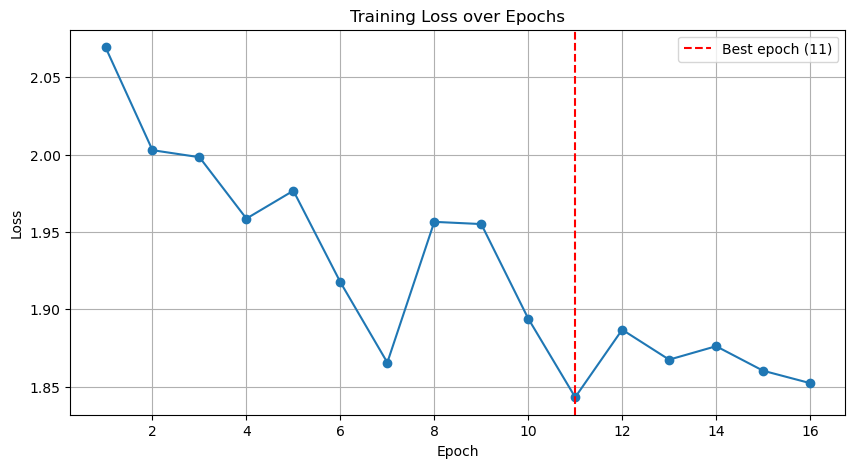

Best loss: 1.843258 at epoch 11
Final loss: 1.852365
Training fold 2/5 with params: {'model_params.hidden_layers': (256, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 159. Best loss was at epoch 154


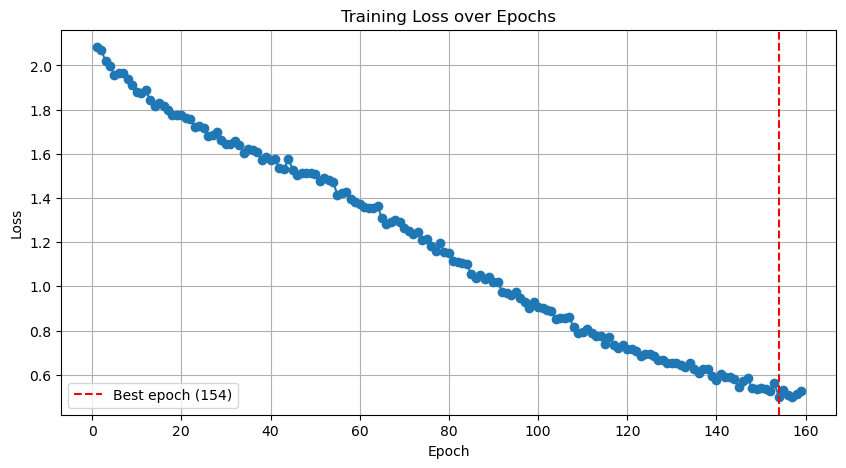

Best loss: 0.498242 at epoch 154
Final loss: 0.524763
Training fold 3/5 with params: {'model_params.hidden_layers': (256, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 128. Best loss was at epoch 123


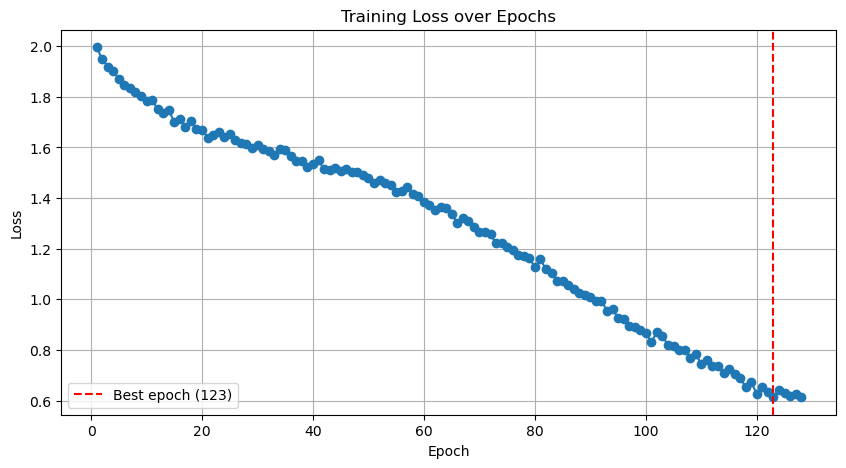

Best loss: 0.613310 at epoch 123
Final loss: 0.613371
Training fold 4/5 with params: {'model_params.hidden_layers': (256, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 167. Best loss was at epoch 162


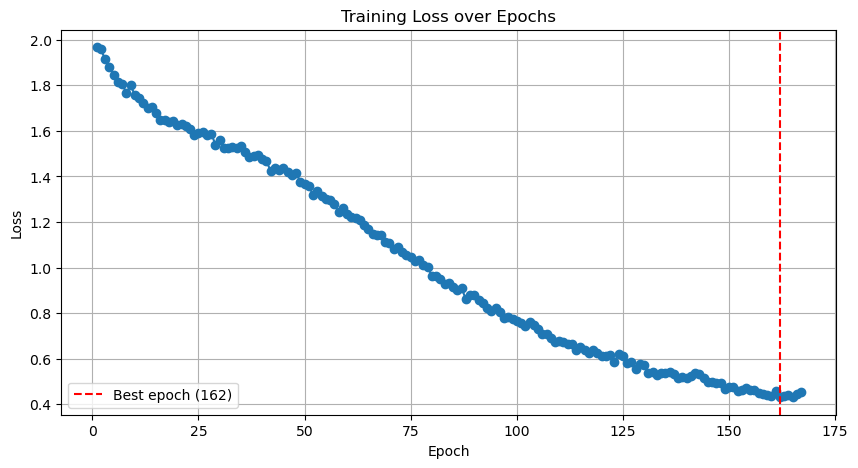

Best loss: 0.430825 at epoch 162
Final loss: 0.455000
Training fold 5/5 with params: {'model_params.hidden_layers': (256, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 147. Best loss was at epoch 142


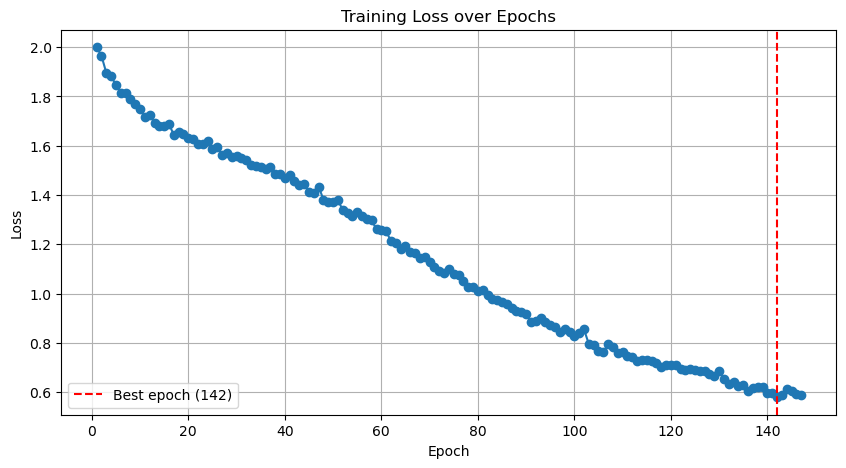

Best loss: 0.579692 at epoch 142
Final loss: 0.590309
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 134. Best loss was at epoch 129


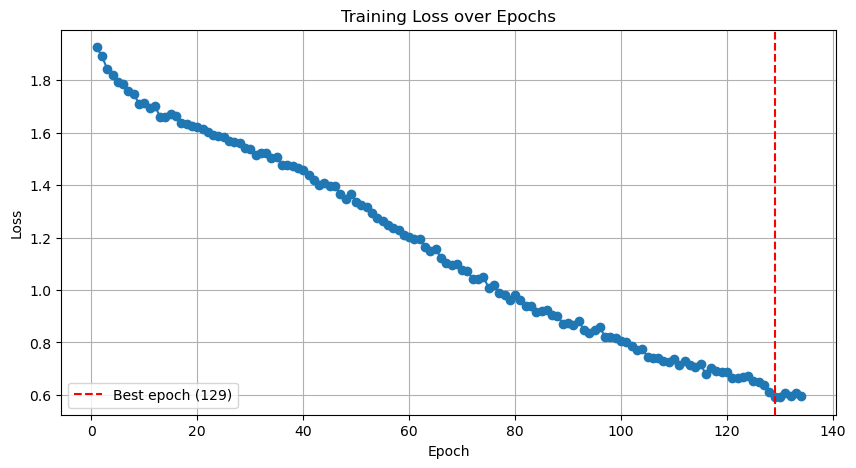

Best loss: 0.590851 at epoch 129
Final loss: 0.597123
{'home_goals_train_accuracy': 0.7745446950710108, 'home_goals_train_precision': 0.4704523006946382, 'home_goals_valid_accuracy': 0.24160401002506265, 'home_goals_valid_precision': 0.13218657693325225, 'home_goals_test_accuracy': 0.24812030075187969, 'home_goals_test_precision': 0.13908472479901052, 'home_goals_train_lte_0_accuracy': 0.9500250626566416, 'home_goals_train_lte_0_accuracy_std': 0.09034016670446317, 'home_goals_train_lte_0_precision': 0.992626111453473, 'home_goals_train_lte_0_precision_std': 0.01023772207613828, 'home_goals_train_eq_1_accuracy': 0.9381620718462823, 'home_goals_train_eq_1_accuracy_std': 0.11446951075933393, 'home_goals_train_eq_1_precision': 0.9107540723306672, 'home_goals_train_eq_1_precision_std': 0.1665462611431007, 'home_goals_train_eq_2_accuracy': 0.8928070175438597, 'home_goals_train_eq_2_accuracy_std': 0.18207518272611373, 'home_goals_train_eq_2_precision': 0.826295813460877, 'home_goals_train_eq_

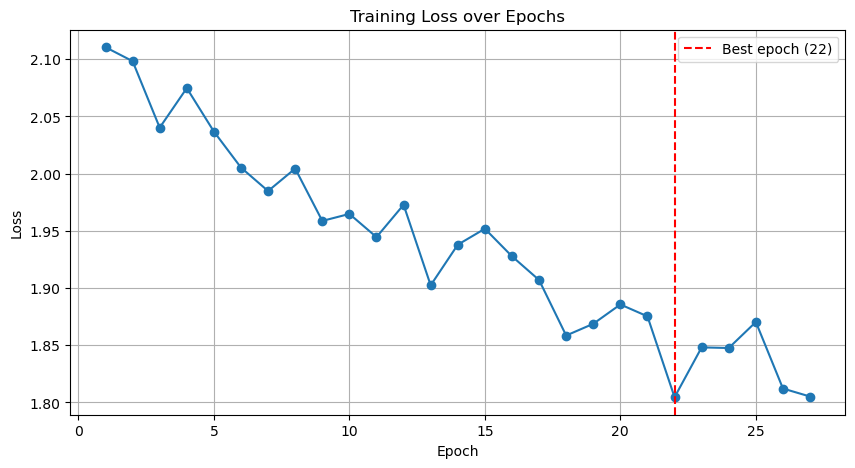

Best loss: 1.804593 at epoch 22
Final loss: 1.805182
Training fold 2/5 with params: {'model_params.hidden_layers': (256, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 123. Best loss was at epoch 118


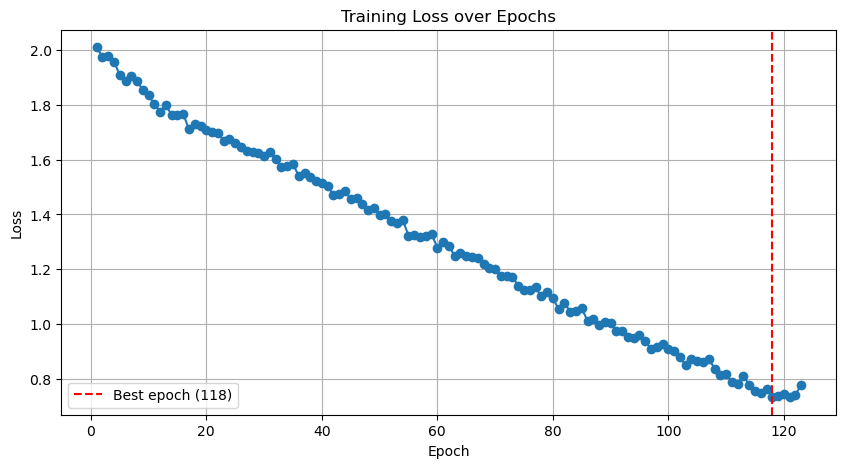

Best loss: 0.733768 at epoch 118
Final loss: 0.777756
Training fold 3/5 with params: {'model_params.hidden_layers': (256, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 166. Best loss was at epoch 161


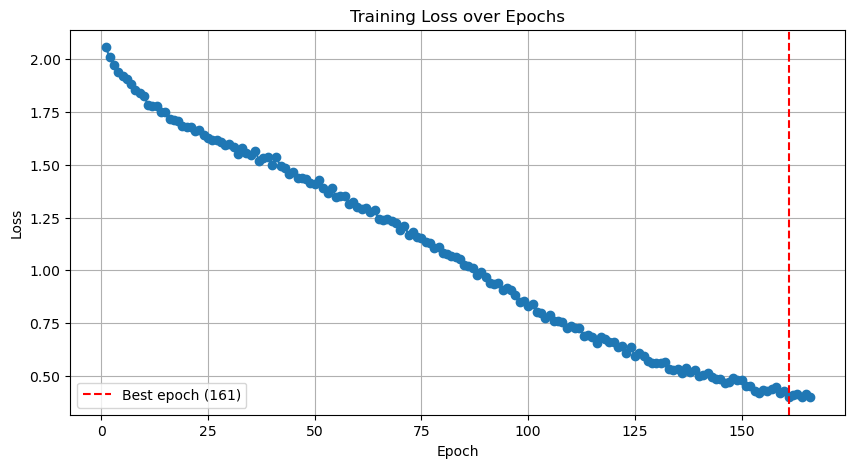

Best loss: 0.398982 at epoch 161
Final loss: 0.401532
Training fold 4/5 with params: {'model_params.hidden_layers': (256, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 124. Best loss was at epoch 119


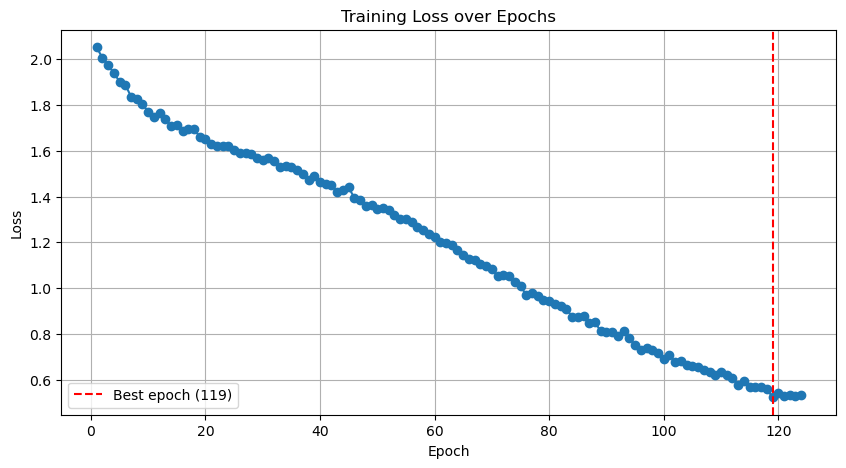

Best loss: 0.522565 at epoch 119
Final loss: 0.531195
Training fold 5/5 with params: {'model_params.hidden_layers': (256, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 154. Best loss was at epoch 149


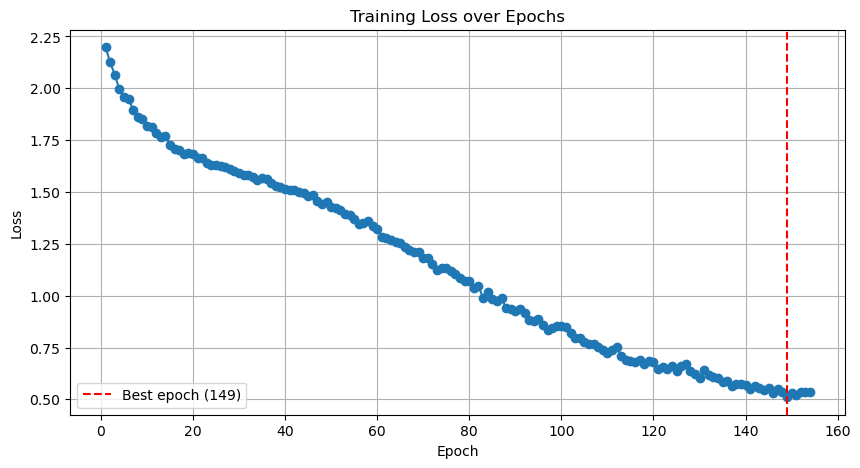

Best loss: 0.510377 at epoch 149
Final loss: 0.533890
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 164. Best loss was at epoch 159


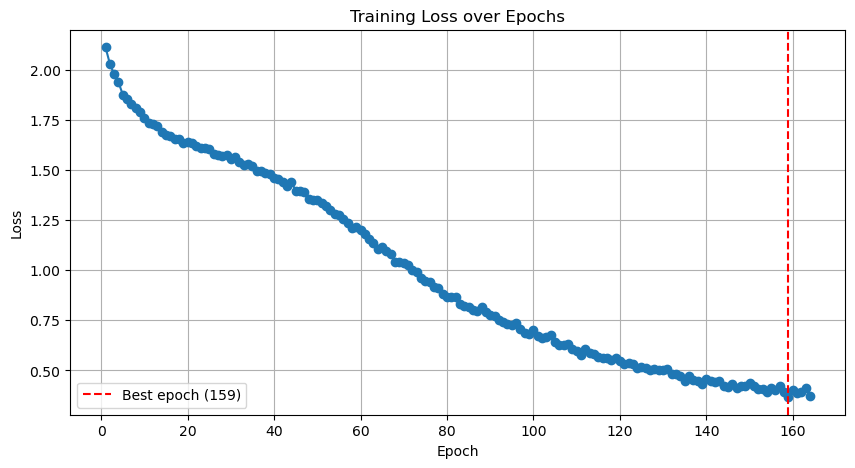

Best loss: 0.366505 at epoch 159
Final loss: 0.374934
{'home_goals_train_accuracy': 0.8138763575605681, 'home_goals_train_precision': 0.5412266345325966, 'home_goals_valid_accuracy': 0.2776942355889724, 'home_goals_valid_precision': 0.14174566821909812, 'home_goals_test_accuracy': 0.23684210526315788, 'home_goals_test_precision': 0.14069162330031895, 'home_goals_train_lte_0_accuracy': 0.9541269841269842, 'home_goals_train_lte_0_accuracy_std': 0.07498474531067945, 'home_goals_train_lte_0_precision': 0.9276030668613136, 'home_goals_train_lte_0_precision_std': 0.11282309984731735, 'home_goals_train_eq_1_accuracy': 0.8838930659983293, 'home_goals_train_eq_1_accuracy_std': 0.16667728518967936, 'home_goals_train_eq_1_precision': 0.8245681711656051, 'home_goals_train_eq_1_precision_std': 0.23429595168541748, 'home_goals_train_eq_2_accuracy': 0.9524728487886381, 'home_goals_train_eq_2_accuracy_std': 0.07782719823427967, 'home_goals_train_eq_2_precision': 0.9237094125269927, 'home_goals_train_e

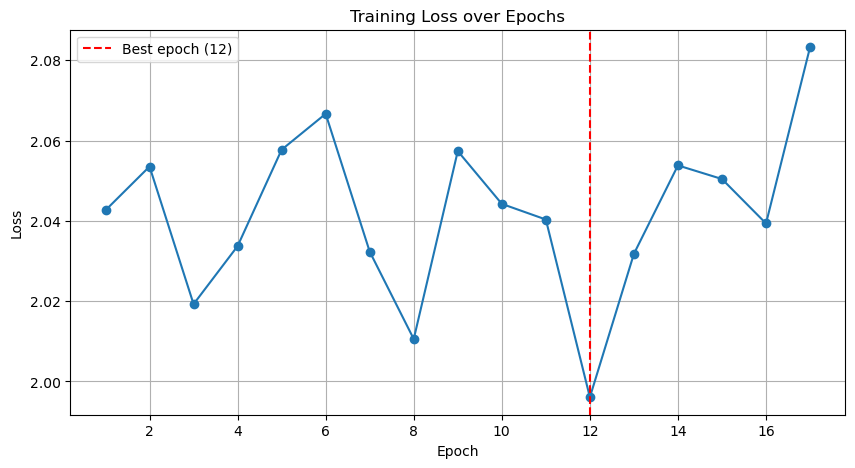

Best loss: 1.996069 at epoch 12
Final loss: 2.083233
Training fold 2/5 with params: {'model_params.hidden_layers': (256, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 10. Best loss was at epoch 5


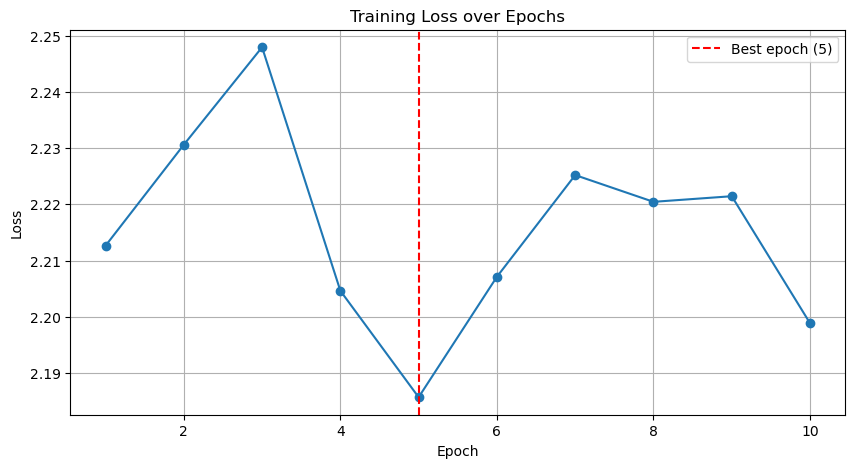

Best loss: 2.185675 at epoch 5
Final loss: 2.198840
Training fold 3/5 with params: {'model_params.hidden_layers': (256, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 11. Best loss was at epoch 6


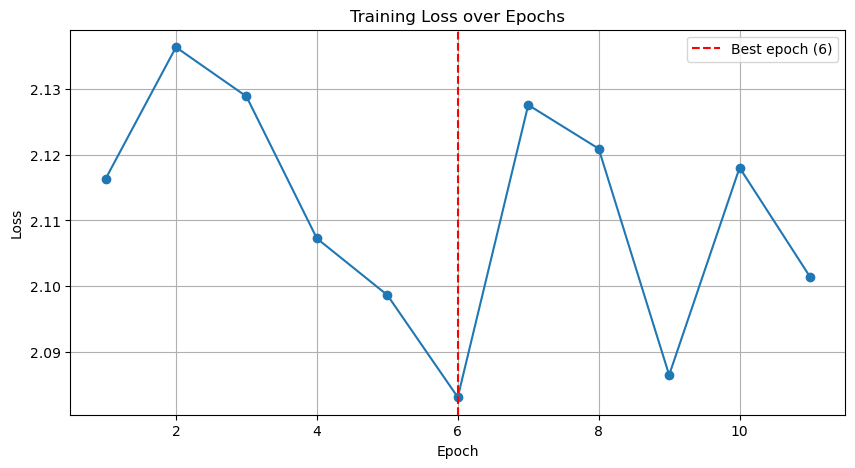

Best loss: 2.083044 at epoch 6
Final loss: 2.101397
Training fold 4/5 with params: {'model_params.hidden_layers': (256, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 18. Best loss was at epoch 13


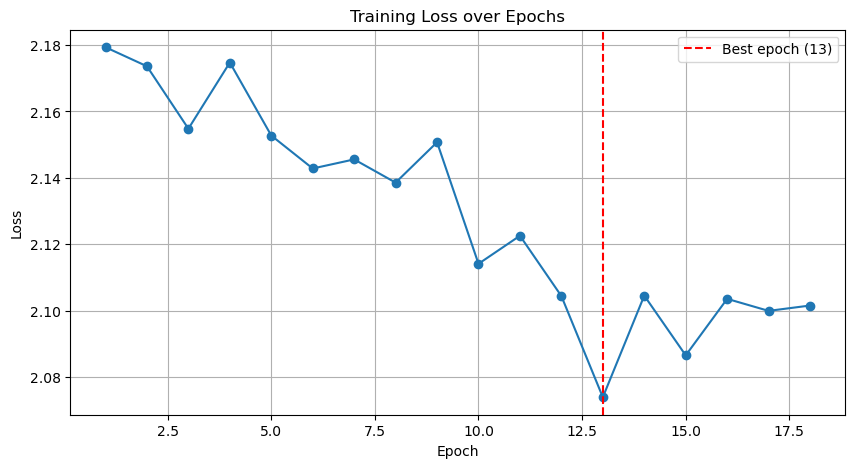

Best loss: 2.073866 at epoch 13
Final loss: 2.101498
Training fold 5/5 with params: {'model_params.hidden_layers': (256, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 58. Best loss was at epoch 53


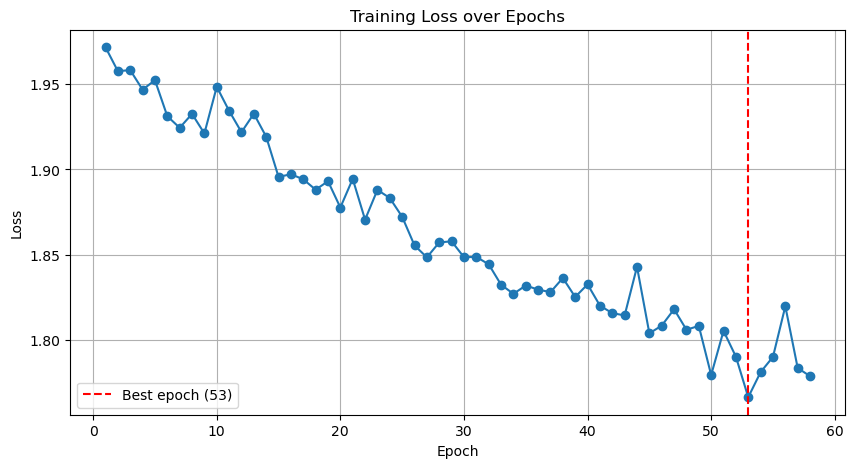

Best loss: 1.766401 at epoch 53
Final loss: 1.778741
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 52. Best loss was at epoch 47


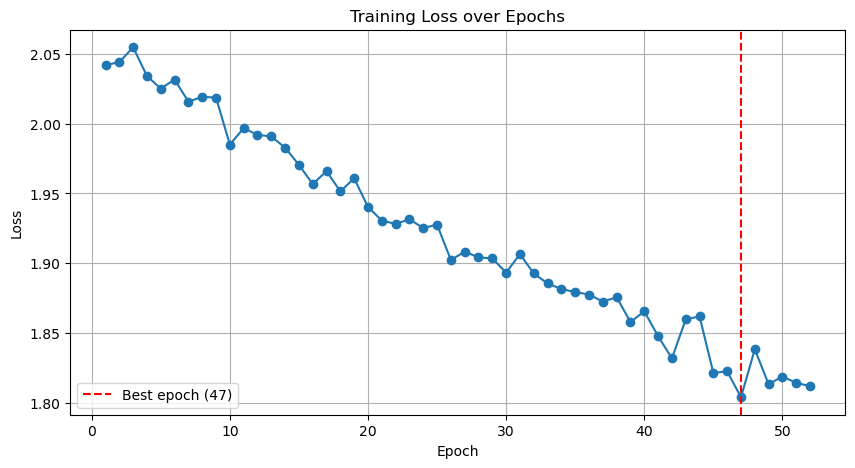

Best loss: 1.804153 at epoch 47
Final loss: 1.812056
{'home_goals_train_accuracy': 0.13225563909774435, 'home_goals_train_precision': 0.14381788412690422, 'home_goals_valid_accuracy': 0.09724310776942355, 'home_goals_valid_precision': 0.11587260536976167, 'home_goals_test_accuracy': 0.23684210526315788, 'home_goals_test_precision': 0.13436226342388807, 'home_goals_train_lte_0_accuracy': 0.7302255639097744, 'home_goals_train_lte_0_accuracy_std': 0.05262312857331686, 'home_goals_train_lte_0_precision': 0.2560468942821884, 'home_goals_train_lte_0_precision_std': 0.21450444873921642, 'home_goals_train_eq_1_accuracy': 0.6804845446950709, 'home_goals_train_eq_1_accuracy_std': 0.007808687985432013, 'home_goals_train_eq_1_precision': 0.27827715355805244, 'home_goals_train_eq_1_precision_std': 0.23889025084860893, 'home_goals_train_eq_2_accuracy': 0.7472514619883042, 'home_goals_train_eq_2_accuracy_std': 0.01436844045787719, 'home_goals_train_eq_2_precision': 0.22961196027768266, 'home_goals_tr

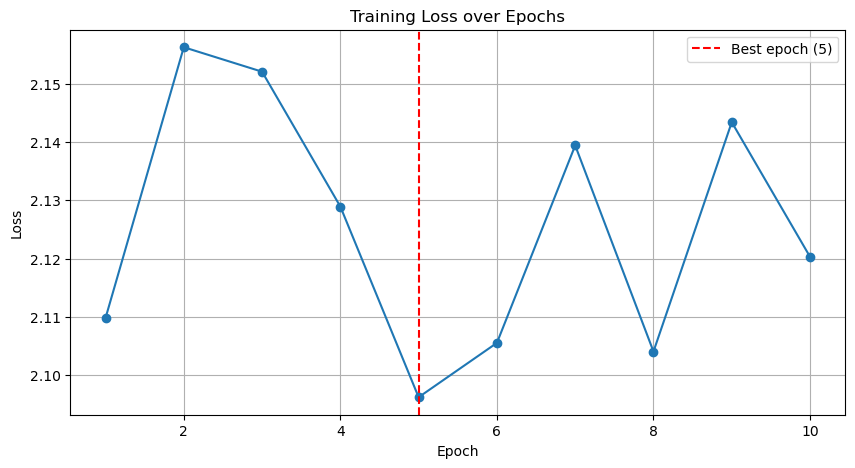

Best loss: 2.096208 at epoch 5
Final loss: 2.120297
Training fold 2/5 with params: {'model_params.hidden_layers': (256, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 11. Best loss was at epoch 6


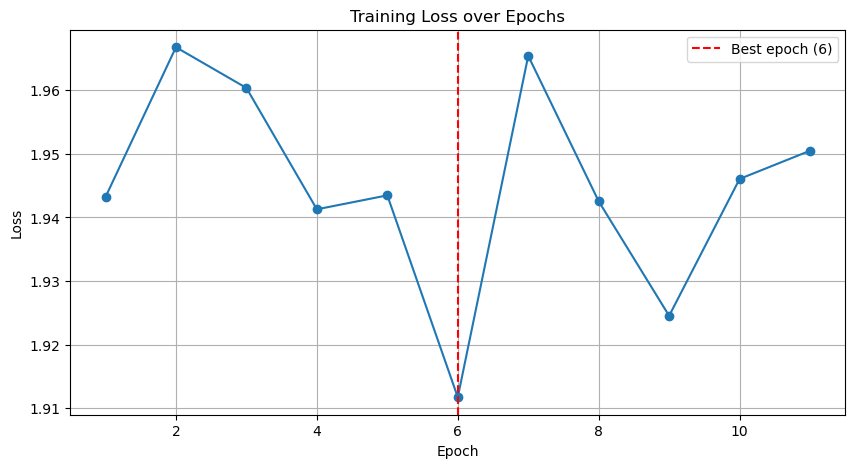

Best loss: 1.911725 at epoch 6
Final loss: 1.950507
Training fold 3/5 with params: {'model_params.hidden_layers': (256, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 26. Best loss was at epoch 21


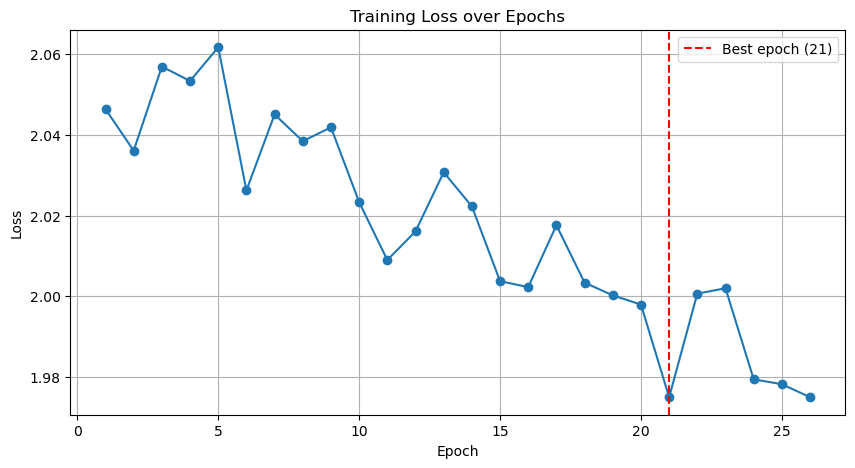

Best loss: 1.974932 at epoch 21
Final loss: 1.974931
Training fold 4/5 with params: {'model_params.hidden_layers': (256, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 38. Best loss was at epoch 33


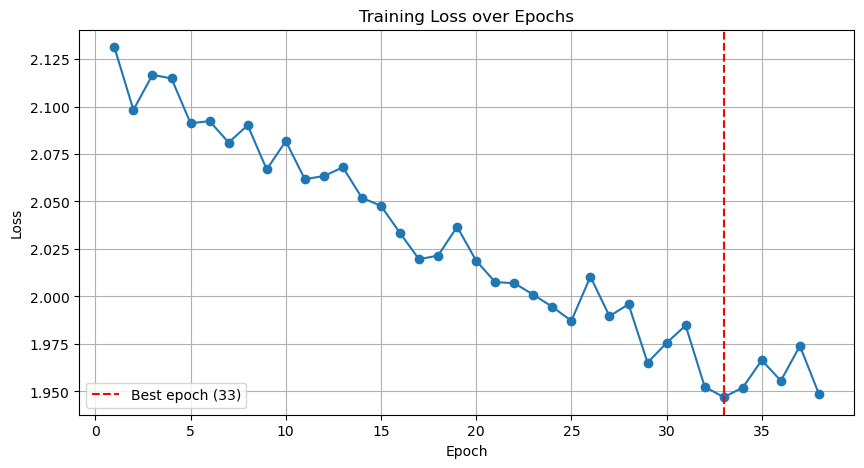

Best loss: 1.946937 at epoch 33
Final loss: 1.948678
Training fold 5/5 with params: {'model_params.hidden_layers': (256, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 26. Best loss was at epoch 21


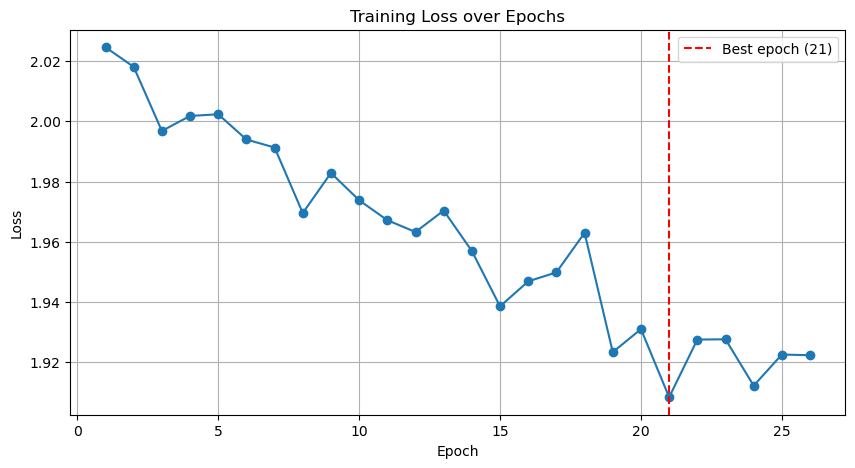

Best loss: 1.908338 at epoch 21
Final loss: 1.922290
[TorchWrapper] Using device: mps


In [ ]:

run_multiclass_distribution_experiment(
    feature_df=feature_df,
    target_df=target_df,
    target_ranges=TRAINGING_CONFIG['target_ranges'],
    model_wrapper_class=lambda **params: TorchWrapper(
        model_class=MLPWithDropoutBN,
        model_params={k.replace('model_params.', ''): v for k, v in params.items() if k.startswith('model_params.')},
        learning_rate=params.get('learning_rate', 0.001),
        batch_size=params.get('batch_size', 64),
        epochs=params.get('epochs', 20)
    ),
    model_param_grid=param_grid,
    test_size=TRAINGING_CONFIG['test_size'],
    k=5,
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    key_columns=TRAINGING_CONFIG['key_columns'],
    uri=f'{REPO_PATH}/mlflow',
    model_name='MLPwithDropoutBN',
    save_model_path=TRAINGING_CONFIG['save_model_path']
)

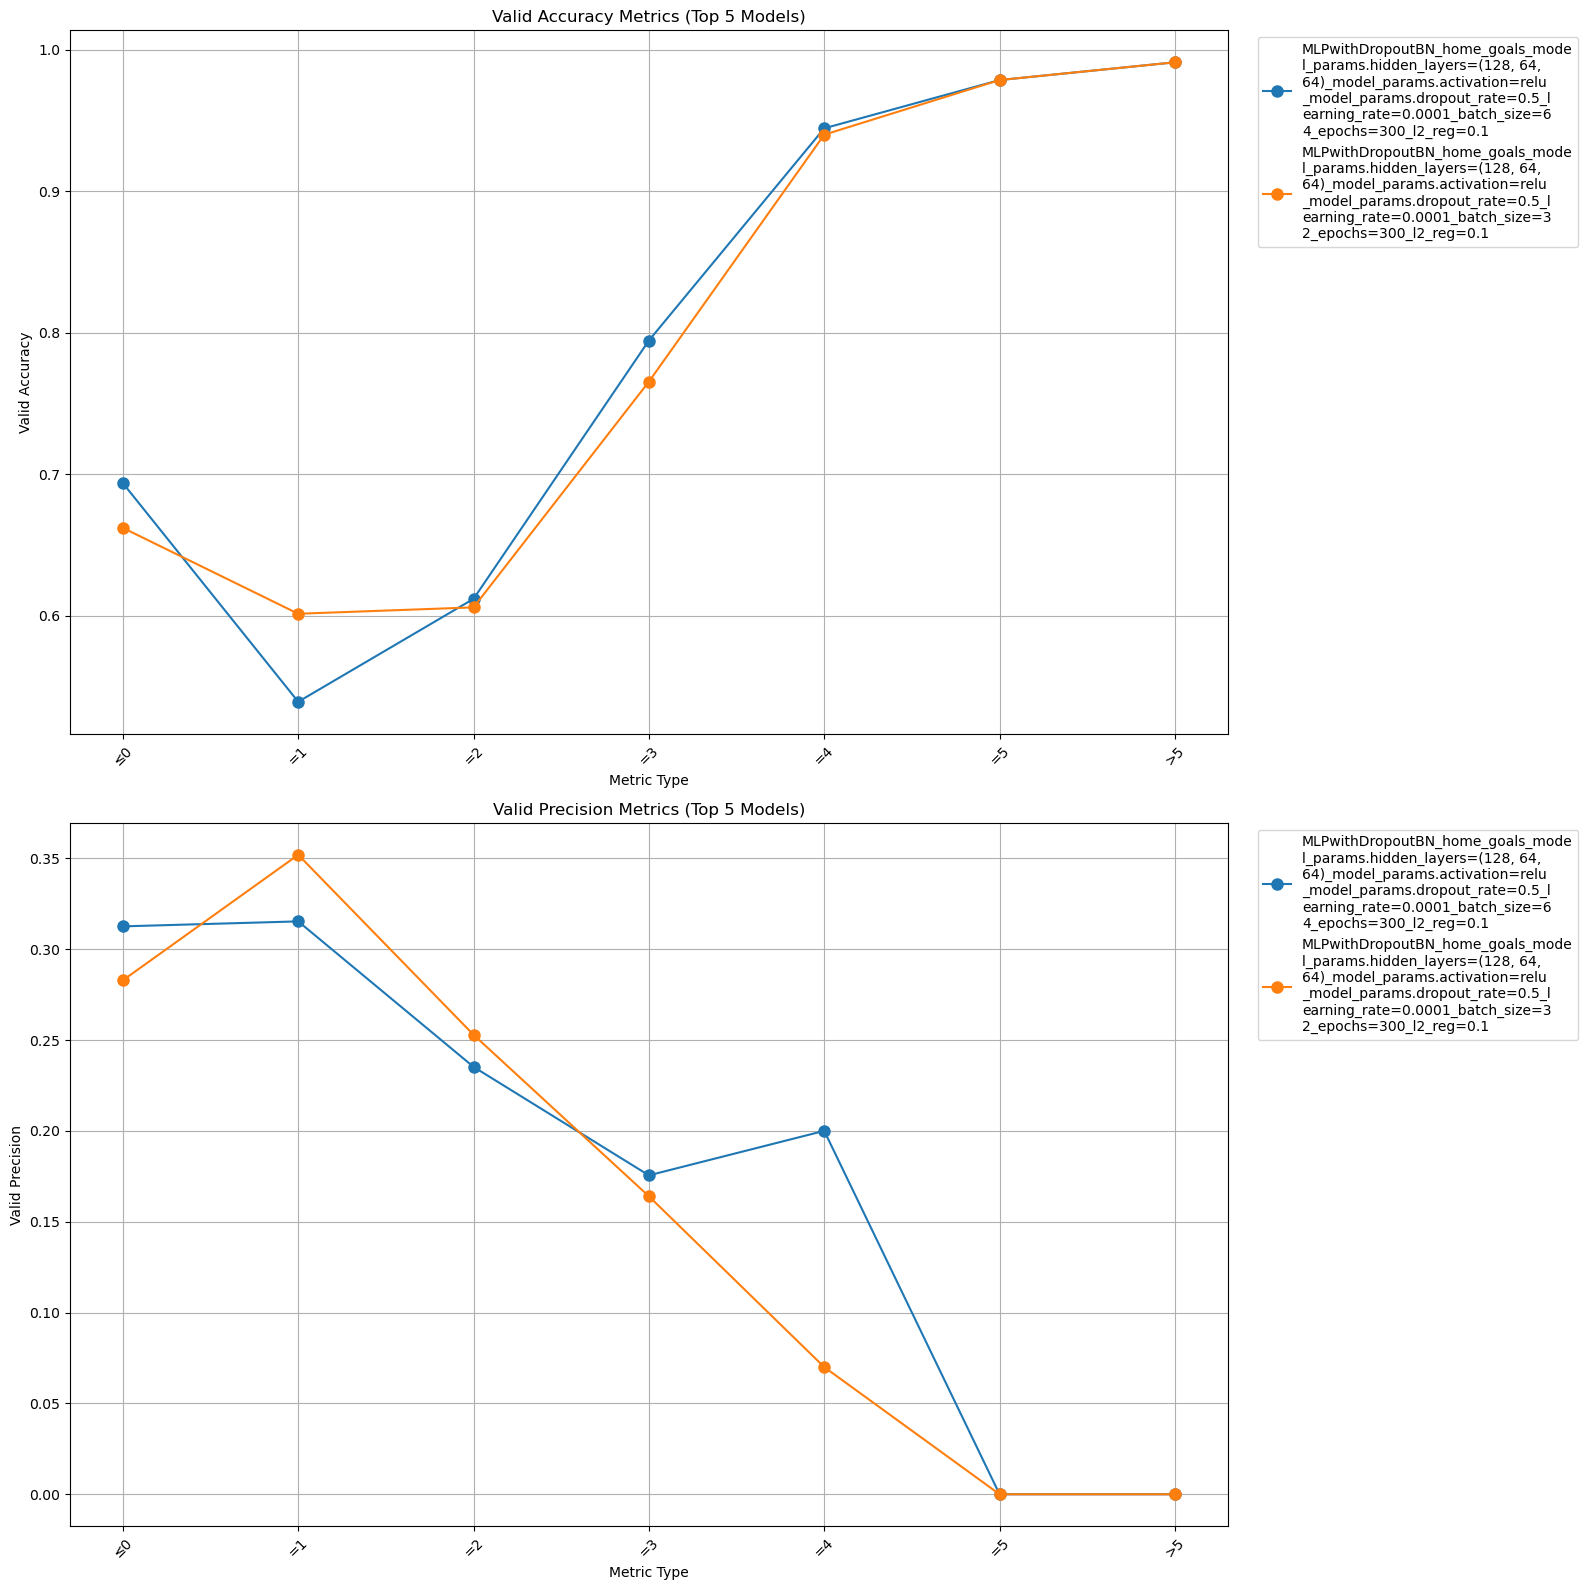

In [ ]:
plot_metrics_for_target_and_model(
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    target_col="home_goals",
    model_name="MLPwithDropoutBN",
    tracking_uri=f"{REPO_PATH}/mlflow"
)

In [9]:
plot_run_metrics_by_split(experiment_name=TRAINGING_CONFIG['experiment_name'],
                         run_name="MLPwithDropoutBN_away_goals_model_params.hidden_layers=(256, 128, 128, 64)_model_params.activation=relu_model_params.dropout_rate=0.1_learning_rate=1e-05_batch_size=64_epochs=2000",
                         target_col="away_goals",
                         tracking_uri=f"{REPO_PATH}/mlflow")

No run found with name 'MLPwithDropoutBN_away_goals_model_params.hidden_layers=(256, 128, 128, 64)_model_params.activation=relu_model_params.dropout_rate=0.1_learning_rate=1e-05_batch_size=64_epochs=2000'.


In [10]:
plot_run_metrics_side_by_side(experiment_name=TRAINGING_CONFIG['experiment_name'],
                              model_name="MLPwithDropoutBN",
                              model_param={'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.00001, 'batch_size': 64, 'epochs': 5000},
                              tracking_uri=f"{REPO_PATH}/mlflow",
                              metric_type="precision")

Searching for runs with filter: params.model_name = 'MLPwithDropoutBN' and params.model_params.hidden_layers= '(512, 256, 256, 128, 128)' and params.model_params.activation= 'relu' and params.model_params.dropout_rate= '0' and params.learning_rate= '1e-05' and params.batch_size= '64' and params.epochs= '5000'
No runs found with model_name 'MLPwithDropoutBN' and params {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}.
